# Exploratory Data Analysis - Monitoring Alert Configurations

This notebook walks through the initial exploration of ~46K alert configurations from a cloud monitoring system. The goal is to understand:
- What kinds of alerts exist and what they're watching
- Which ones actually fire (and how often)
- Whether there are patterns that could help predict noisy or incident-prone alerts

The modeling work (training, tuning, and comparing classifiers) lives in the separate [Modeling notebook](Modeling.ipynb).

## Setup

In [79]:
import os, re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

os.chdir(os.path.join(os.path.expanduser('~'), 'Documents', 'MLandAI', 'capstone'))

## Load the data

In [80]:
df_raw = pd.read_csv('data/argus_alerts_v2_masked.csv')
print(f"Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
df_raw.head(3)

Shape: 46,559 rows, 31 columns


,alert_id,alert_name,expression,cron_entry,enabled,owner_name,alert_type,shared,created_date,modified_date,...,clear_inertia_ms,enable_clear_threshold,has_pagerduty,notification_names,triggered_count,target_incident,is_noisy_alert,pd_incident_count,pd_mean_ttr_seconds,pd_total_escalations
0,127781169,Acme: product-1167.service-3287.CP.us-east-1-k...,GENERATE_TAG(\n GENERATE_TAG(\n -20m:-5m:s...,*/5 * * * *,True,owner-0001,REACTIVE,False,2025-05-07T15:02:17.028000+00:00,2025-08-19T14:43:17.073000+00:00,...,NaN,False,False,notification-1,0,0,0,0,0.0,0
1,127781159,Acme: product-1167.service-2965.CP.us-east-1-k...,GENERATE_TAG(\n GENERATE_TAG(\n -20m:-5m:s...,*/5 * * * *,True,owner-0001,REACTIVE,False,2025-05-07T15:02:06.751000+00:00,2025-08-19T14:43:23.271000+00:00,...,NaN,False,False,notification-1,0,0,0,0,0.0,0
2,138680162,Acme: product-1115.service-2461.rds.disk_queue...,-15m:-5m:acme_cloudwatchexporter.aws_rds.aws.e...,*/10 * * * *,True,owner-0001,REACTIVE,False,2025-10-23T17:54:35.839000+00:00,2025-10-23T17:56:09.878000+00:00,...,300000.0,True,True,notification-1; notification-2; notification-3,0,0,0,0,0.0,0


In [81]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 46559 entries, 0 to 46558
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   alert_id                   46559 non-null  int64  
 1   alert_name                 46559 non-null  str    
 2   expression                 46559 non-null  str    
 3   cron_entry                 46559 non-null  str    
 4   enabled                    46559 non-null  bool   
 5   owner_name                 46559 non-null  str    
 6   alert_type                 46559 non-null  str    
 7   shared                     46559 non-null  bool   
 8   created_date               46559 non-null  str    
 9   modified_date              46559 non-null  str    
 10  trigger_id                 46494 non-null  float64
 11  trigger_name               46494 non-null  str    
 12  trigger_type               46494 non-null  str    
 13  threshold                  46494 non-null  float64
 14  s

In [82]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
alert_id,46559.0,NaN,NaN,NaN,128544373.961898,24709826.914595,72799158.0,114059694.0,135771368.0,147434077.5,155295307.0
alert_name,46559,36664,Acme: service-2898.service-0182.rds.freeableme...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
expression,46559,33793,REVERSE_PROPAGATE(PROPAGATE(\n SCALE(\n GR...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cron_entry,46559,26,*/10 * * * *,19232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enabled,46559,2,True,44406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner_name,46559,1,owner-0001,46559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alert_type,46559,3,REACTIVE,46191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shared,46559,2,False,46377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_date,46559,36619,2024-04-09T16:28:34.118000+00:00,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modified_date,46559,36661,2026-04-25T05:51:03.086000+00:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

### Deduplication

So each row is actually an alert+trigger pair - one alert can have a warning trigger AND a critical trigger, each with its own threshold. I need to keep those separate but drop any real duplicates (same alert_id + trigger_id appearing twice).

In [83]:
print(f"Total rows: {len(df_raw):,}")
print(f"Unique alert_id: {df_raw['alert_id'].nunique():,}")
print(f"Unique trigger_id: {df_raw['trigger_id'].nunique():,}")

triggers_per_alert = df_raw.groupby('alert_id')['trigger_id'].nunique()
print(f"\nTriggers per alert:")
print(f"  1 trigger:  {(triggers_per_alert == 1).sum():,}")
print(f"  2 triggers: {(triggers_per_alert == 2).sum():,}")
print(f"  3+ triggers: {(triggers_per_alert >= 3).sum():,}")

# quick sanity check - show one alert that has multiple triggers
multi_ids = triggers_per_alert[triggers_per_alert > 1].index
example = df_raw[df_raw['alert_id'] == multi_ids[0]][['alert_id', 'trigger_name', 'trigger_type', 'threshold', 'triggered_count']]
print(f"\nExample multi-trigger alert:")
print(example.to_string(index=False))

true_dupes = df_raw.duplicated(subset=['alert_id', 'trigger_id']).sum()
print(f"\nTrue duplicates: {true_dupes:,}")
df = df_raw.drop_duplicates(subset=['alert_id', 'trigger_id']).copy()
print(f"After dedup: {len(df):,} rows")

Total rows: 46,559
Unique alert_id: 36,664
Unique trigger_id: 45,900

Triggers per alert:
  1 trigger:  27,316
  2 triggers: 9,277
  3+ triggers: 10

Example multi-trigger alert:
 alert_id                                                                  trigger_name trigger_type  threshold  triggered_count
 73842633  service-1169-InfraAlert (Ecache)-elasticache-redis-memory_usage-warning-kdev GREATER_THAN        4.5                0
 73842633 service-1169-InfraAlert (Ecache)-elasticache-redis-memory_usage-critical-kdev GREATER_THAN        4.0                0

True duplicates: 598
After dedup: 45,961 rows


### Missing values

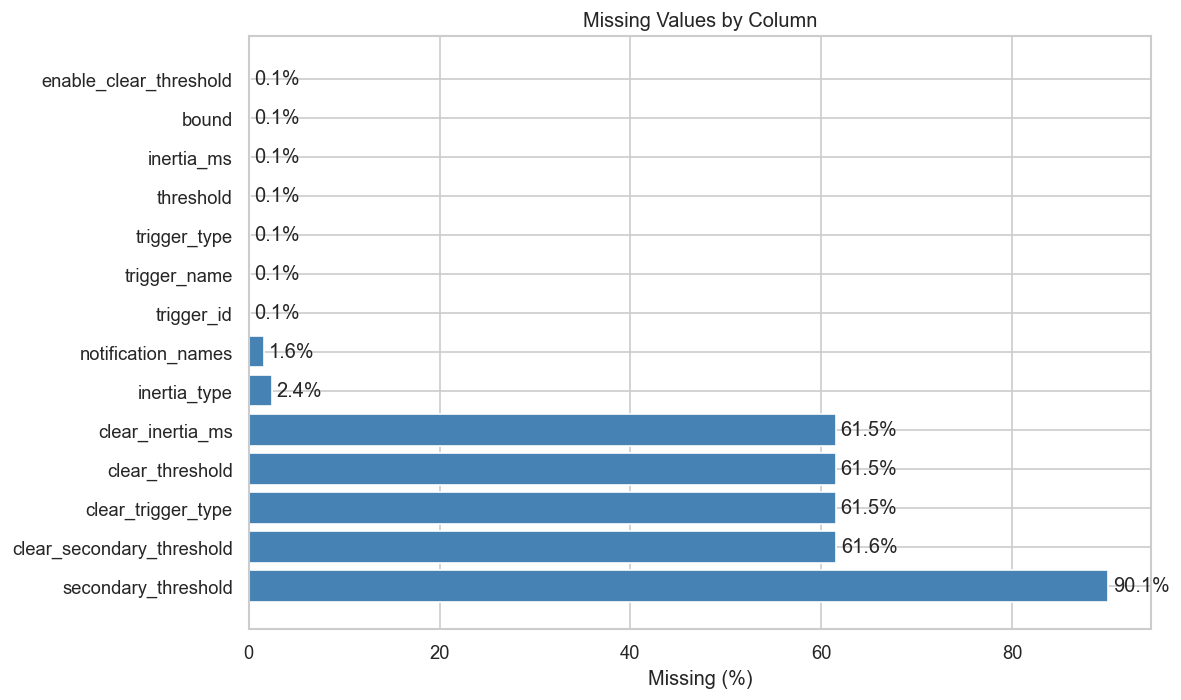

,count,pct
secondary_threshold,41427,90.1
clear_secondary_threshold,28328,61.6
clear_trigger_type,28250,61.5
clear_threshold,28250,61.5
clear_inertia_ms,28252,61.5
inertia_type,1101,2.4
notification_names,721,1.6
trigger_id,61,0.1
trigger_name,61,0.1
trigger_type,61,0.1


In [84]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(missing_df.index, missing_df['pct'], color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column')
for bar, pct in zip(bars, missing_df['pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{pct}%', va='center')
plt.tight_layout()
plt.show()

missing_df

### Parse dates and create some time-based features

In [85]:
df['created_date'] = pd.to_datetime(df['created_date'], format='ISO8601', utc=True)
df['modified_date'] = pd.to_datetime(df['modified_date'], format='ISO8601', utc=True)

df['created_month'] = df['created_date'].dt.to_period('M').astype(str)
df['days_since_modified'] = (df['modified_date'].max() - df['modified_date']).dt.days
df['alert_age_days'] = (df['modified_date'] - df['created_date']).dt.days

### Feature engineering

Going to pull out some useful features from the alert names and expressions - things like what metric the alert is watching, which environment it's in, which product it belongs to, etc.

In [86]:
# classify what each alert is monitoring based on keywords in the expression
metric_rules = [
    ('apdex',           r'apdex'),
    ('apm_duration',    r'apm_duration|latency|_p50_|_p95_|_p99_|cpa_duration'),
    ('error_rate',      r'error.rate|error_rate|apm_error|err_count|status_code|5xx|4xx|apm_\[request\|response\]_count'),
    ('request_rate',    r'request_rate|req.rate|throughput|RequestCount|apm_request_count'),
    ('cpu',             r'[Cc][Pp][Uu]|cpu_usage_seconds'),
    ('memory',          r'[Mm]emory|RSS|heap|MemoryUtilization|oomkilled|OOMKilled'),
    ('disk',            r'[Dd]isk|volume|percent_bytes\.free'),
    ('rds_database',    r'rds|RDS|DatabaseConnections|DiskQueueDepth|FreeableMemory'),
    ('redis_cache',     r'redis|elasticache|Redis|Elasticache'),
    ('queue_backlog',   r'[Qq]ueue|backlog|SQS|dlq|dead_letter'),
    ('availability',    r'availability|uptime|health'),
    ('pod_restart',     r'pod.restart|restart_count|CrashLoopBackOff|kube_pod_container_status_restarts'),
    ('network',         r'[Nn]etwork|[Bb]andwidth|PacketsIn|PacketsOut|nginx|connections_accepted'),
    ('synthetic',       r'synthetic'),
    ('kube_infra',      r'kube_daemonset|kube_deployment|kube_statefulset|kube_node'),
    ('anomaly',         r'sqlQuery|formattedSQL|anomaly'),
    ('jvm',             r'jvm|gc_pause|GarbageCollection'),
]

def classify_metric(expr):
    if pd.isna(expr):
        return 'unknown'
    for name, pattern in metric_rules:
        if re.search(pattern, expr):
            return name
    return 'other'

df['metric_category'] = df['expression'].apply(classify_metric)

# figure out the environment from the alert name
def extract_environment(name):
    name_lower = str(name).lower()
    if any(x in name_lower for x in ['kstg', '-stg', '.stg', '_stg', 'staging']):
        return 'staging'
    elif any(x in name_lower for x in ['-prod', '.prod', '_prod', 'prod1', 'prod2', 'prod3']):
        return 'production'
    elif any(x in name_lower for x in ['-dev', '.dev', '_dev', 'mdev']):
        return 'development'
    elif any(x in name_lower for x in ['-uat', '.uat']):
        return 'uat'
    elif any(x in name_lower for x in ['-perf', '.perf', '-qa', '.qa', 'kqa']):
        return 'qa'
    return 'production'  # default assumption

df['environment'] = df['alert_name'].apply(extract_environment)

# product and region from alert name
df['product'] = df['alert_name'].str.extract(r'(product-\d+)', expand=False).fillna('unknown')
df['region'] = df['alert_name'].str.extract(
    r'(us-east-1|eu-central-1|us-west-2|eu-west-1|ap-northeast-1|ap-southeast-[12])', expand=False
).fillna('unspecified')

# convert cron schedule to check interval in minutes
def cron_to_minutes(cron):
    m = re.match(r'\*/?(\d+)', str(cron))
    if m:
        return int(m.group(1))
    if str(cron).startswith('0 '):
        return 60
    return None

df['check_interval_min'] = df['cron_entry'].apply(cron_to_minutes)

# how many notification channels each alert has
df['notification_count'] = df['notification_names'].str.count(';') + 1
df.loc[df['notification_names'].isna(), 'notification_count'] = 0

print(f"New shape: {df.shape}")
df[['alert_name', 'metric_category', 'environment', 'product', 'region', 'check_interval_min', 'notification_count']].head(10)

New shape: (45961, 40)


,alert_name,metric_category,environment,product,region,check_interval_min,notification_count
0,Acme: product-1167.service-3287.CP.us-east-1-k...,apm_duration,staging,product-1167,us-east-1,5.0,1.0
1,Acme: product-1167.service-2965.CP.us-east-1-k...,apm_duration,staging,product-1167,us-east-1,5.0,1.0
2,Acme: product-1115.service-2461.rds.disk_queue...,disk,production,product-1115,unspecified,10.0,3.0
3,Acme: product-1115.service-2461.rds.disk_queue...,disk,production,product-1115,unspecified,10.0,3.0
4,Acme: product-1167.service-3287.CP.us-east-1-k...,apm_duration,staging,product-1167,us-east-1,5.0,1.0
5,Acme: product-1167.service-1775.rds-stg-kstg-u...,rds_database,staging,product-1167,us-east-1,10.0,2.0
6,Acme: product-1167.service-1775.rds-stg-kstg-u...,rds_database,staging,product-1167,us-east-1,10.0,2.0
7,Acme: product-1855.service-2393.elasticache-re...,memory,development,product-1855,unspecified,10.0,2.0
8,Acme: product-1855.service-2393.elasticache-re...,memory,development,product-1855,unspecified,10.0,2.0
9,Acme: product-1167.service-1775.rds-stg-kstg-u...,rds_database,staging,product-1167,us-east-1,10.0,2.0


## Visualizations

### What are people monitoring?

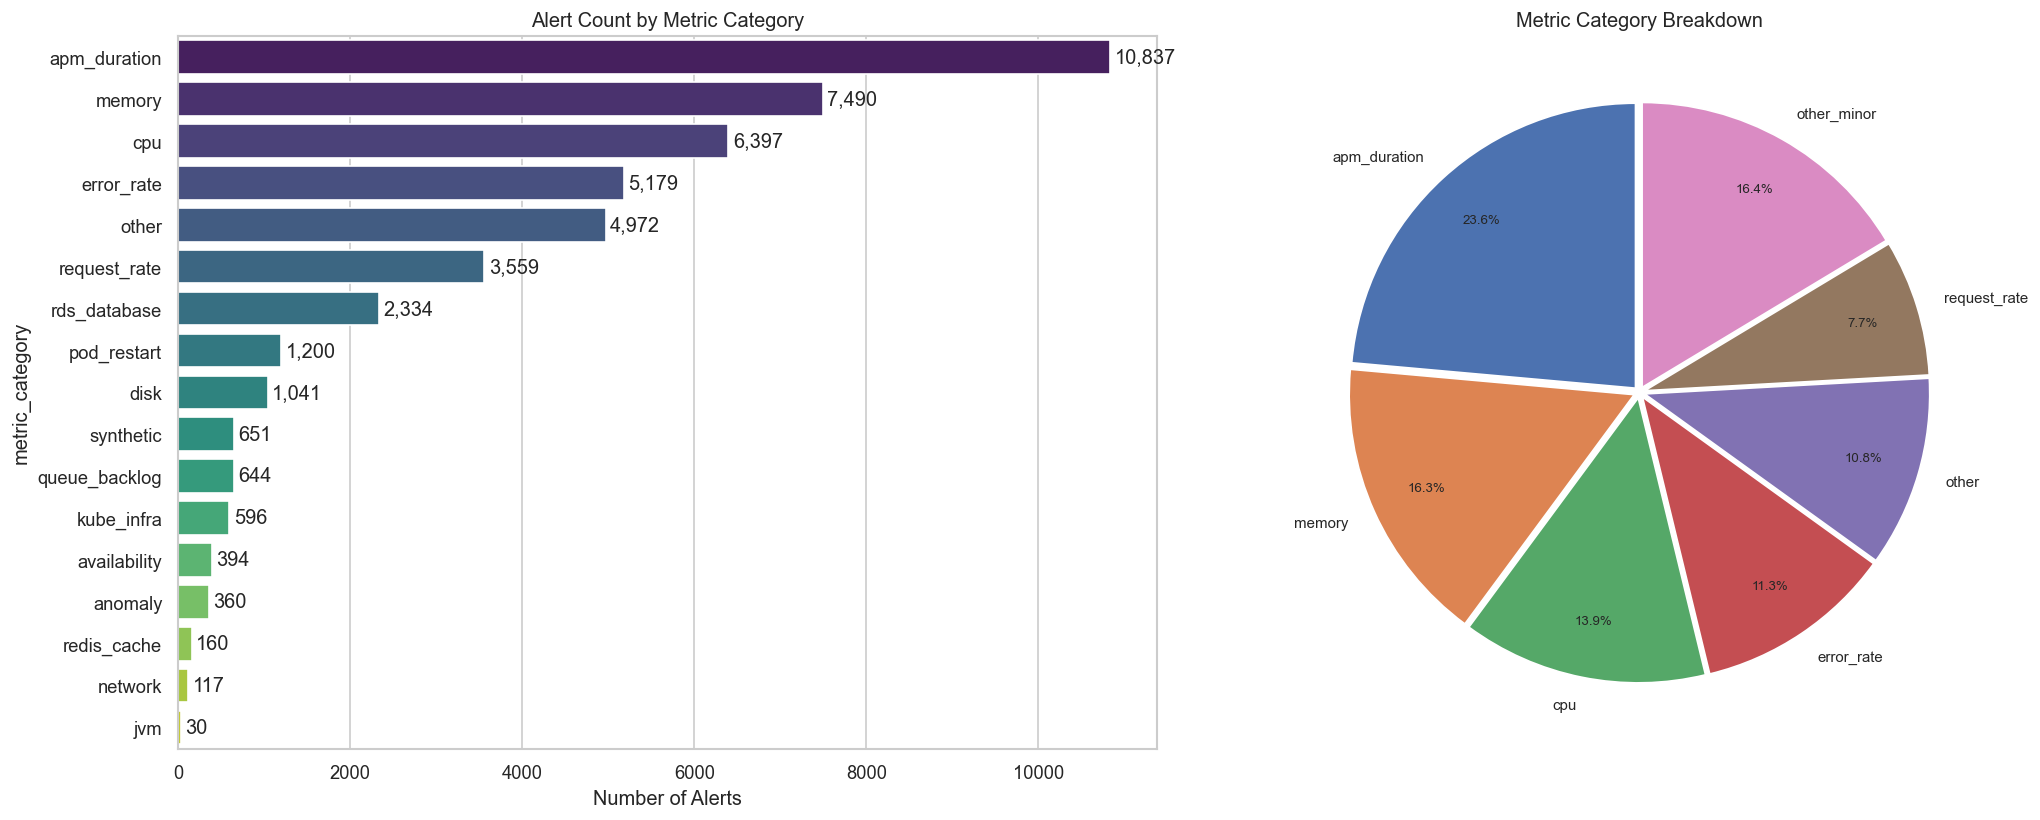

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

metric_counts = df['metric_category'].value_counts()
sns.barplot(x=metric_counts.values, y=metric_counts.index, ax=axes[0], palette='viridis')
axes[0].set_title('Alert Count by Metric Category')
axes[0].set_xlabel('Number of Alerts')
for i, v in enumerate(metric_counts.values):
    axes[0].text(v + 50, i, f'{v:,}', va='center')

# group the small categories so the pie chart isn't a mess
top_metrics = metric_counts.head(6)
minor_sum = metric_counts.iloc[6:].sum()
pie_data = pd.concat([top_metrics, pd.Series({'other_minor': minor_sum})])
explode = [0.02] * len(pie_data)
wedges, texts, autotexts = axes[1].pie(
    pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
    startangle=90, pctdistance=0.80, explode=explode,
    textprops={'fontsize': 9}
)
for t in autotexts:
    t.set_fontsize(8)
axes[1].set_title('Metric Category Breakdown')

plt.tight_layout()
plt.show()

### Environment breakdown

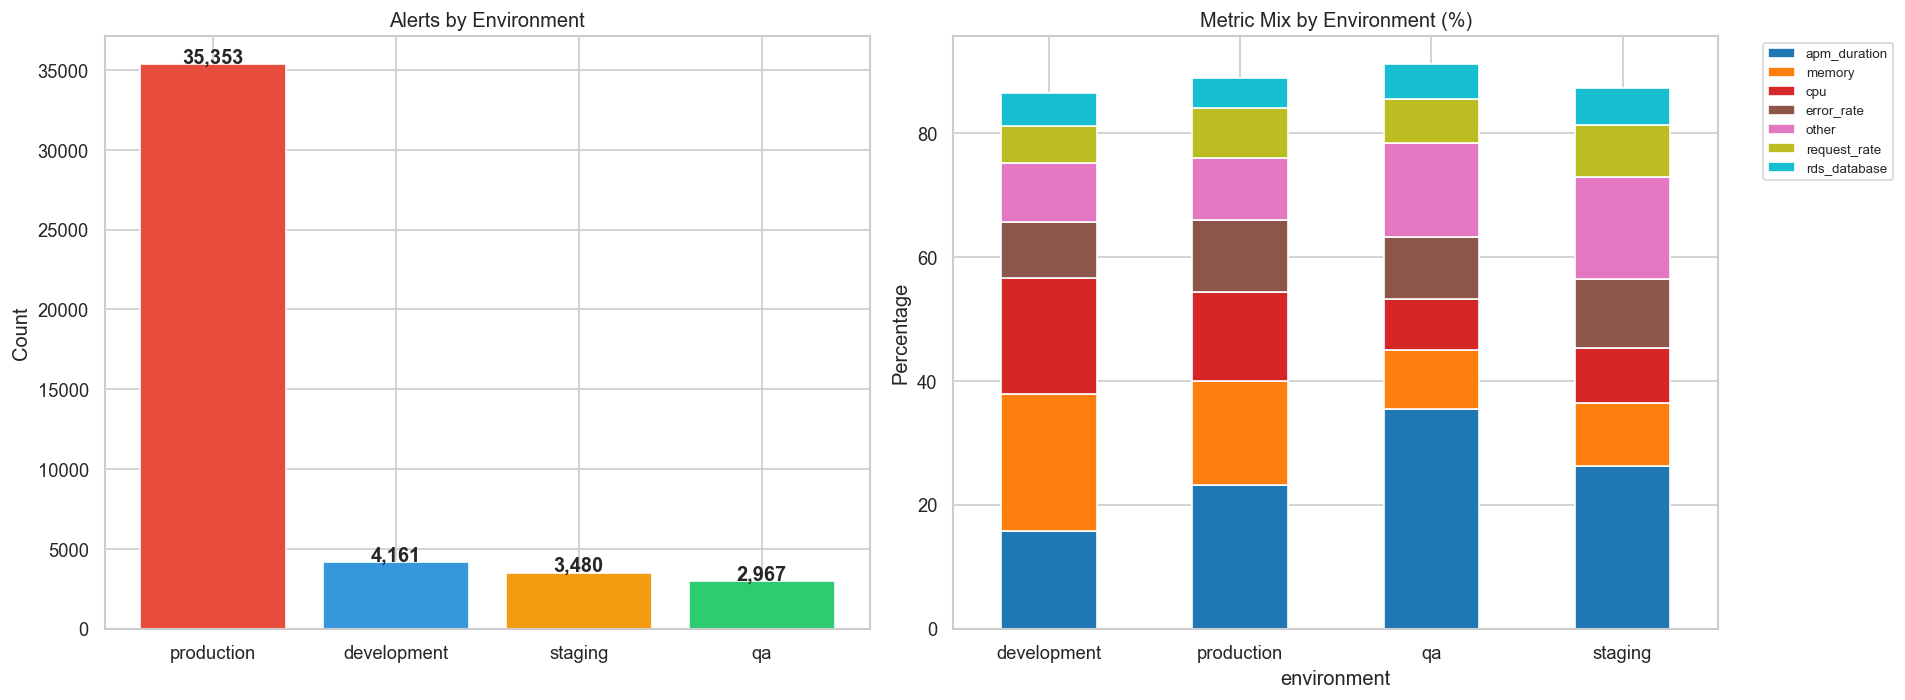

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

env_counts = df['environment'].value_counts()
colors = {'production': '#e74c3c', 'staging': '#f39c12', 'development': '#3498db', 'qa': '#2ecc71', 'uat': '#9b59b6'}
bar_colors = [colors.get(e, '#95a5a6') for e in env_counts.index]
axes[0].bar(env_counts.index, env_counts.values, color=bar_colors)
axes[0].set_title('Alerts by Environment')
axes[0].set_ylabel('Count')
for i, v in enumerate(env_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

ct = pd.crosstab(df['metric_category'], df['environment'], normalize='columns') * 100
top_cats = df['metric_category'].value_counts().head(7).index
ct.loc[top_cats].T.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10')
axes[1].set_title('Metric Mix by Environment (%)')
axes[1].set_ylabel('Percentage')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Which products have the most alerts?

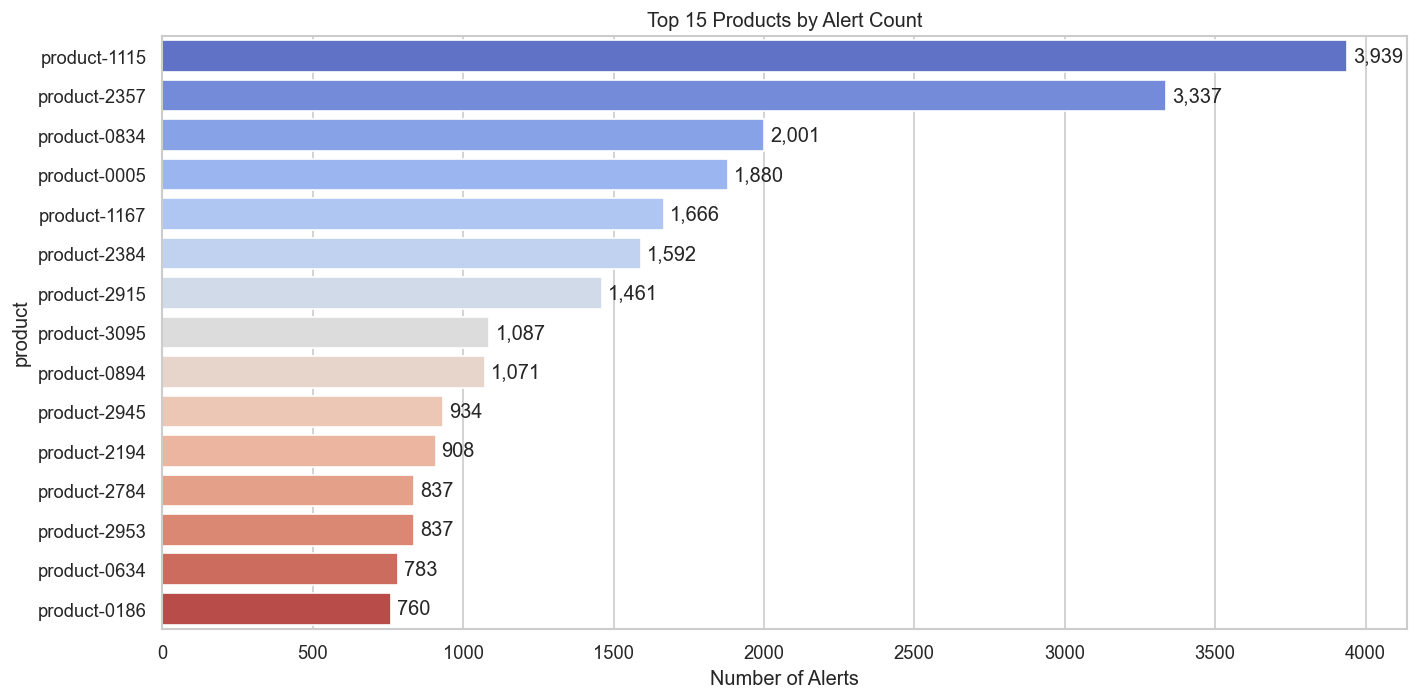

In [89]:
top_products = df[df['product'] != 'unknown']['product'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='coolwarm', ax=ax)
ax.set_title('Top 15 Products by Alert Count')
ax.set_xlabel('Number of Alerts')
for i, v in enumerate(top_products.values):
    ax.text(v + 20, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()

In [90]:
# interactive version - easier to explore the product/metric breakdown
product_metric = df[df['product'] != 'unknown'].groupby(['product', 'metric_category']).size().reset_index(name='count')
product_metric = product_metric[product_metric['product'].isin(top_products.index)]

fig = px.treemap(product_metric, path=['product', 'metric_category'], values='count',
                 title='Top Products — Alert Breakdown by Metric Category',
                 color='count', color_continuous_scale='Blues')
fig.update_layout(height=600)
fig.show()

### How often do alerts actually fire?

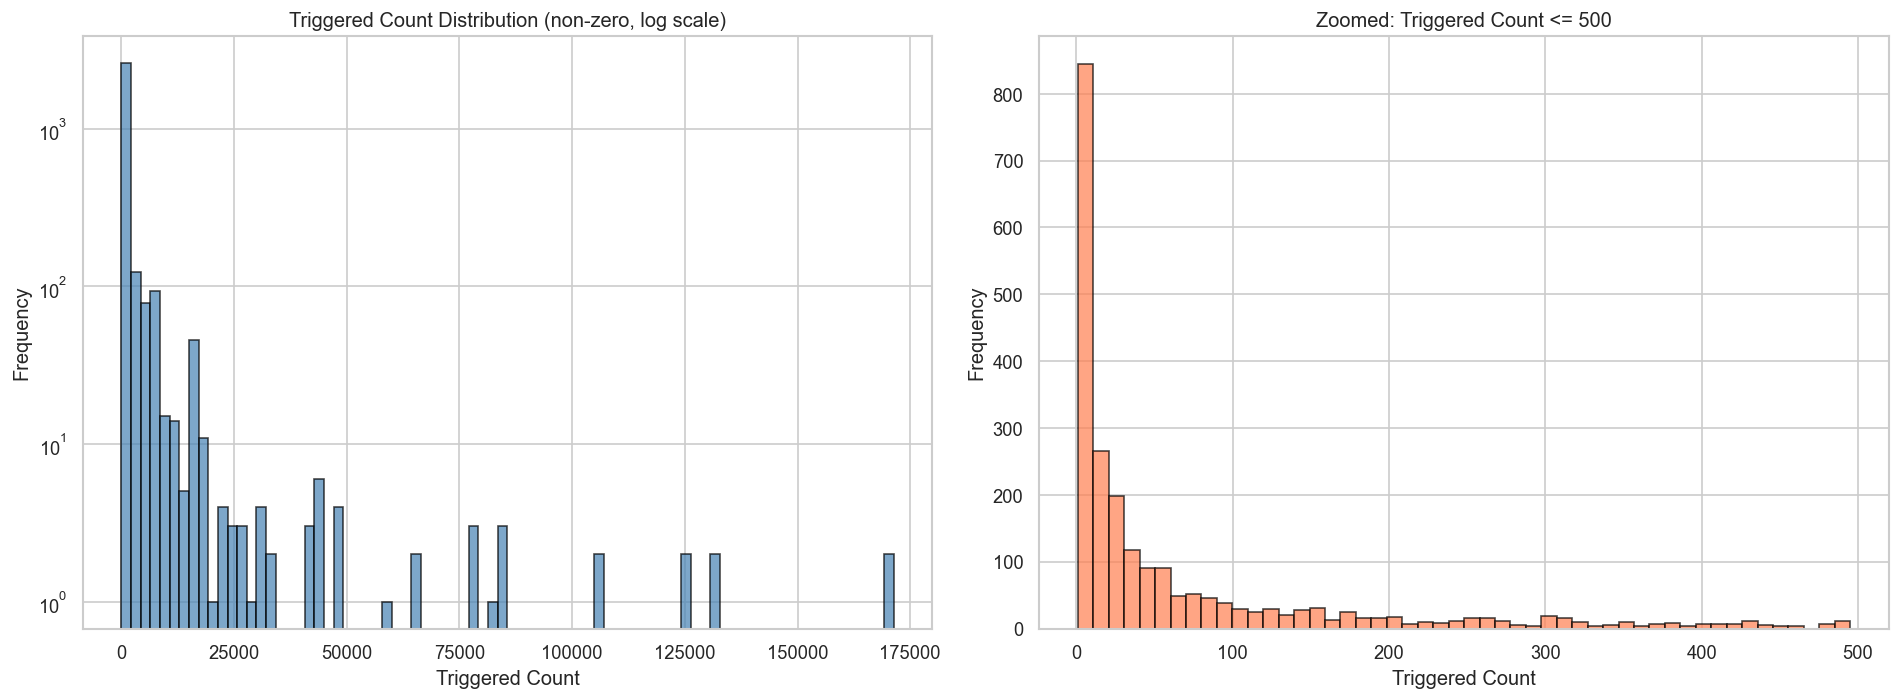

Never triggered: 42,910 (93.4%)
Triggered at least once: 3,051
Max: 171,306


In [91]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

triggered = df['triggered_count']
axes[0].hist(triggered[triggered > 0], bins=80, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_yscale('log')
axes[0].set_title('Triggered Count Distribution (non-zero, log scale)')
axes[0].set_xlabel('Triggered Count')
axes[0].set_ylabel('Frequency')

triggered_low = triggered[(triggered > 0) & (triggered <= 500)]
axes[1].hist(triggered_low, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Zoomed: Triggered Count <= 500')
axes[1].set_xlabel('Triggered Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Never triggered: {(triggered == 0).sum():,} ({(triggered == 0).mean()*100:.1f}%)")
print(f"Triggered at least once: {(triggered > 0).sum():,}")
print(f"Max: {triggered.max():,}")

### PagerDuty - do alerts with paging behave differently?

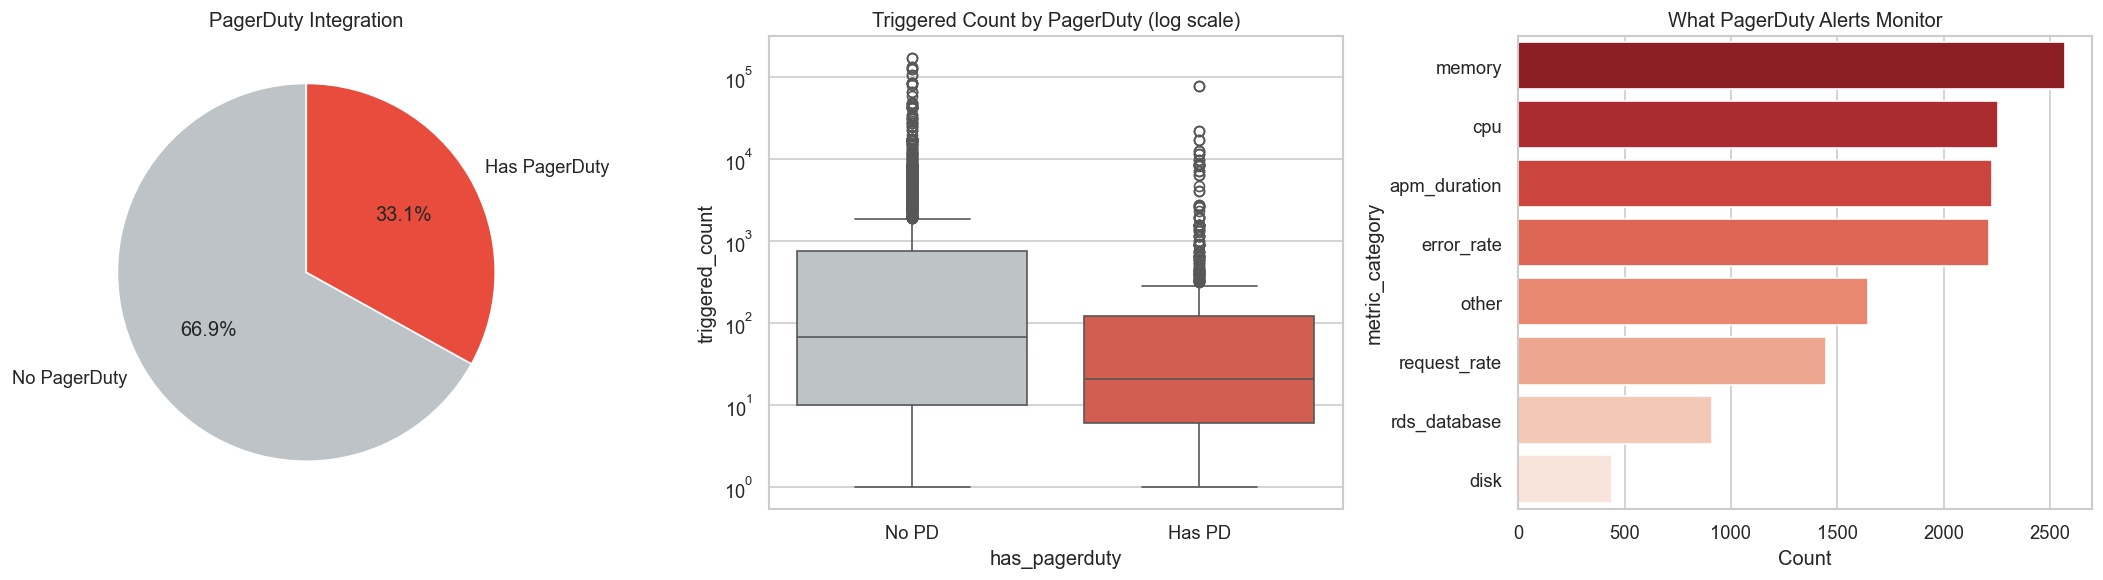

Triggered count stats - PagerDuty vs not:
                mean  50%  75%       max
has_pagerduty                           
False          188.9  0.0  0.0  171306.0
True            33.0  0.0  0.0   78373.0


In [92]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pd_counts = df['has_pagerduty'].value_counts()
axes[0].pie(pd_counts.values, labels=['No PagerDuty', 'Has PagerDuty'],
            autopct='%1.1f%%', colors=['#bdc3c7', '#e74c3c'], startangle=90)
axes[0].set_title('PagerDuty Integration')

triggered_nonzero = df[df['triggered_count'] > 0]
sns.boxplot(data=triggered_nonzero, x='has_pagerduty', y='triggered_count', ax=axes[1],
            palette=['#bdc3c7', '#e74c3c'])
axes[1].set_yscale('log')
axes[1].set_title('Triggered Count by PagerDuty (log scale)')
axes[1].set_xticklabels(['No PD', 'Has PD'])

pd_alerts = df[df['has_pagerduty'] == True]
pd_metrics = pd_alerts['metric_category'].value_counts().head(8)
sns.barplot(x=pd_metrics.values, y=pd_metrics.index, ax=axes[2], palette='Reds_r')
axes[2].set_title('What PagerDuty Alerts Monitor')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

print("Triggered count stats - PagerDuty vs not:")
print(df.groupby('has_pagerduty')['triggered_count'].describe()[['mean', '50%', '75%', 'max']].round(1))

### Trigger types and inertia

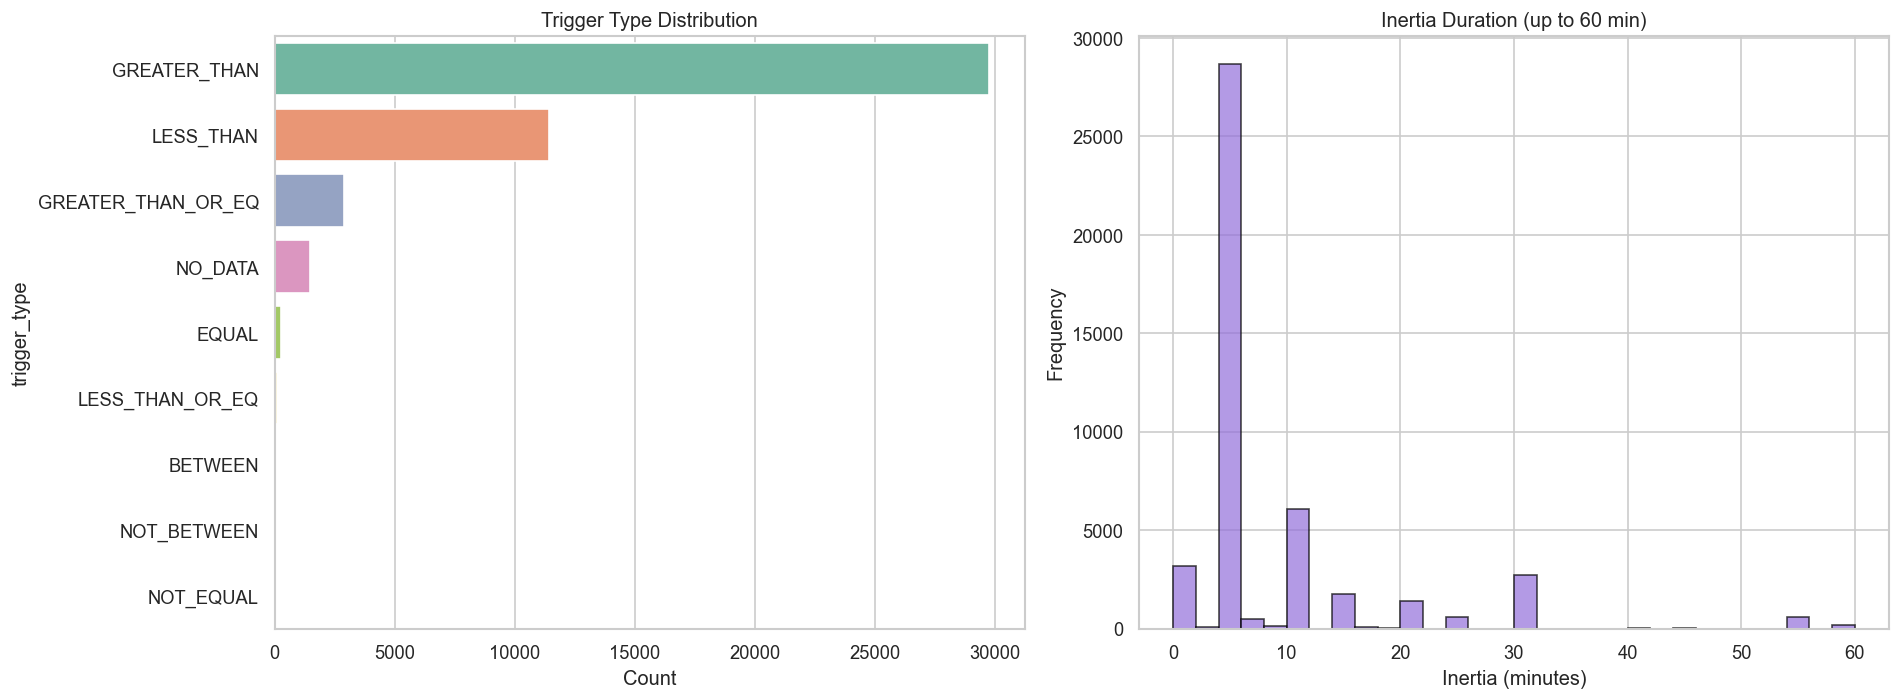

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

trigger_counts = df['trigger_type'].value_counts()
sns.barplot(x=trigger_counts.values, y=trigger_counts.index, ax=axes[0], palette='Set2')
axes[0].set_title('Trigger Type Distribution')
axes[0].set_xlabel('Count')

inertia = df['inertia_ms'].dropna() / 60000
axes[1].hist(inertia[inertia <= 60], bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1].set_title('Inertia Duration (up to 60 min)')
axes[1].set_xlabel('Inertia (minutes)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Check intervals

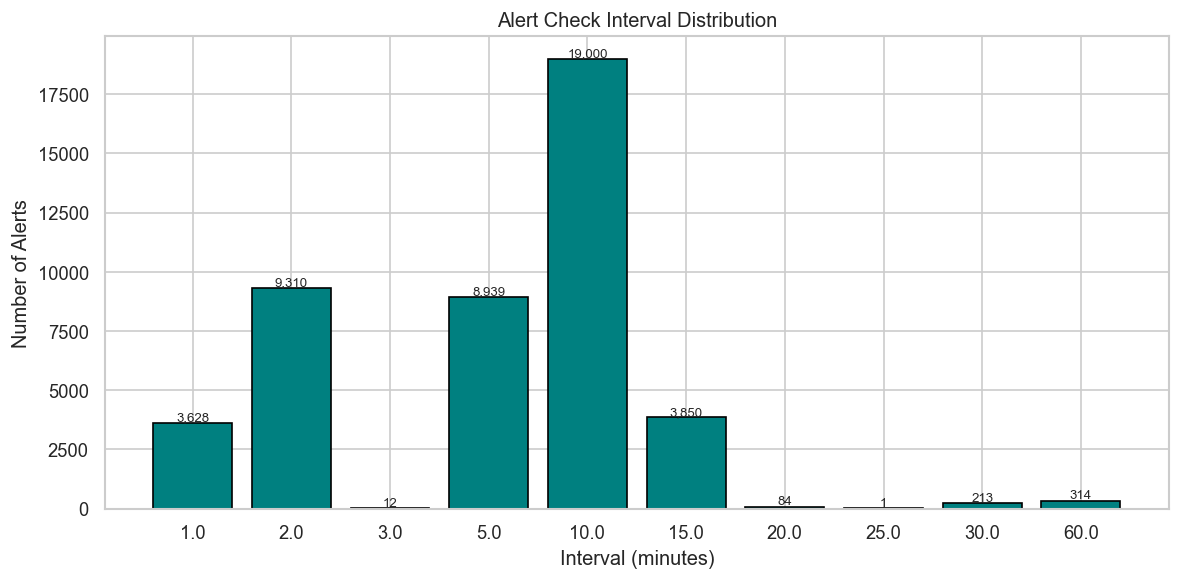

In [94]:
fig, ax = plt.subplots(figsize=(10, 5))
interval_counts = df['check_interval_min'].value_counts().sort_index()
ax.bar(interval_counts.index.astype(str), interval_counts.values, color='teal', edgecolor='black')
ax.set_title('Alert Check Interval Distribution')
ax.set_xlabel('Interval (minutes)')
ax.set_ylabel('Number of Alerts')
for i, (idx, v) in enumerate(interval_counts.items()):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### When were alerts created?

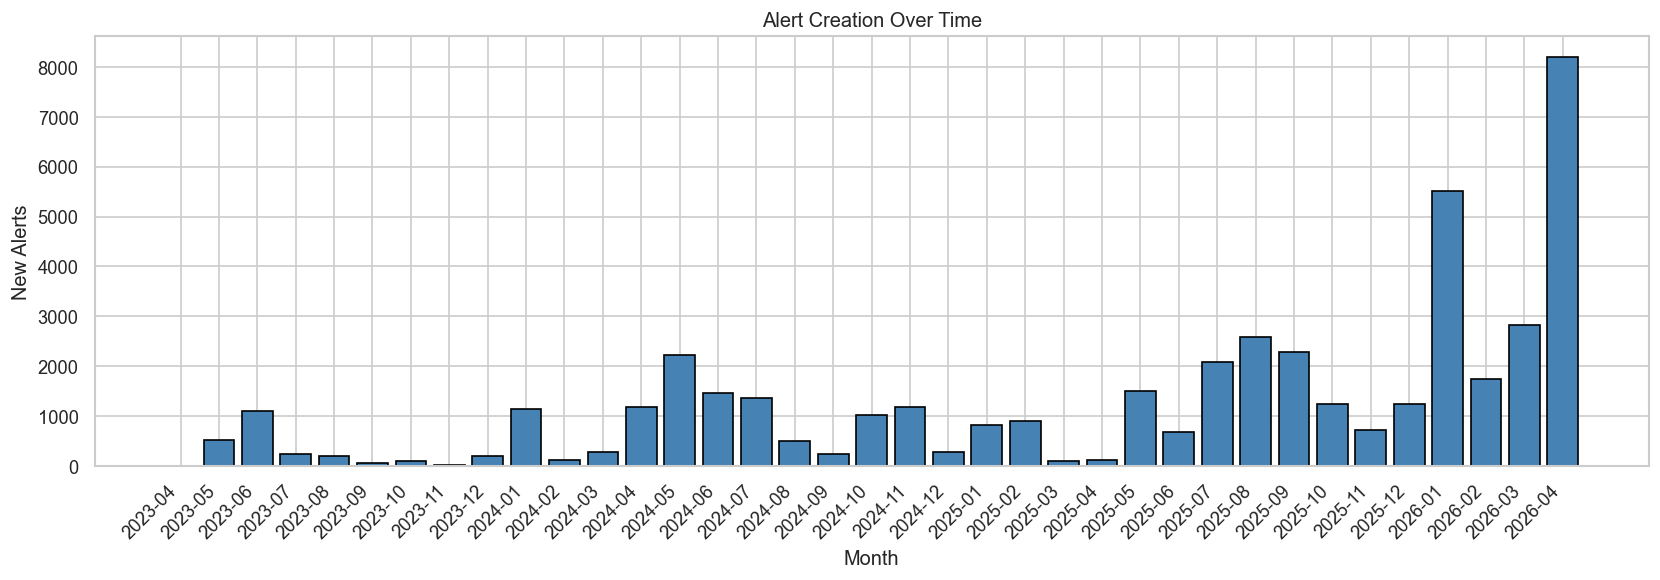

In [95]:
monthly = df.groupby('created_month').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly['created_month'], monthly['count'], color='steelblue', edgecolor='black')
ax.set_title('Alert Creation Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('New Alerts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Correlations between numeric features

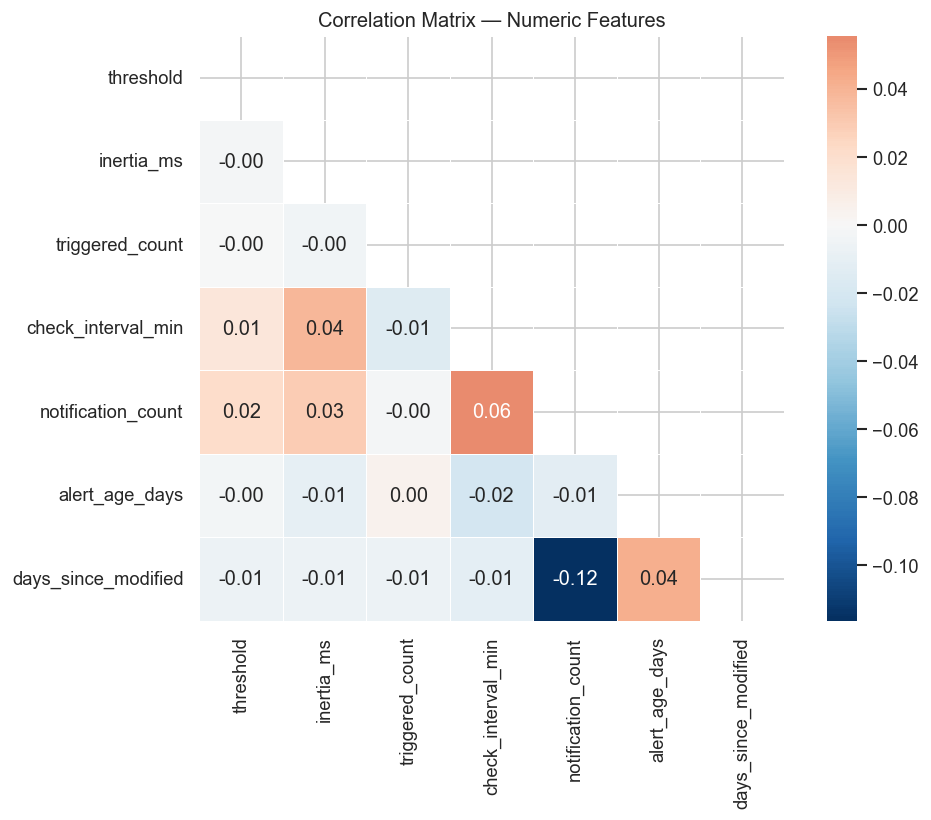

In [96]:
numeric_cols = ['threshold', 'inertia_ms', 'triggered_count', 'check_interval_min',
                'notification_count', 'alert_age_days', 'days_since_modified']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

### Heatmap - avg trigger count by metric category and environment

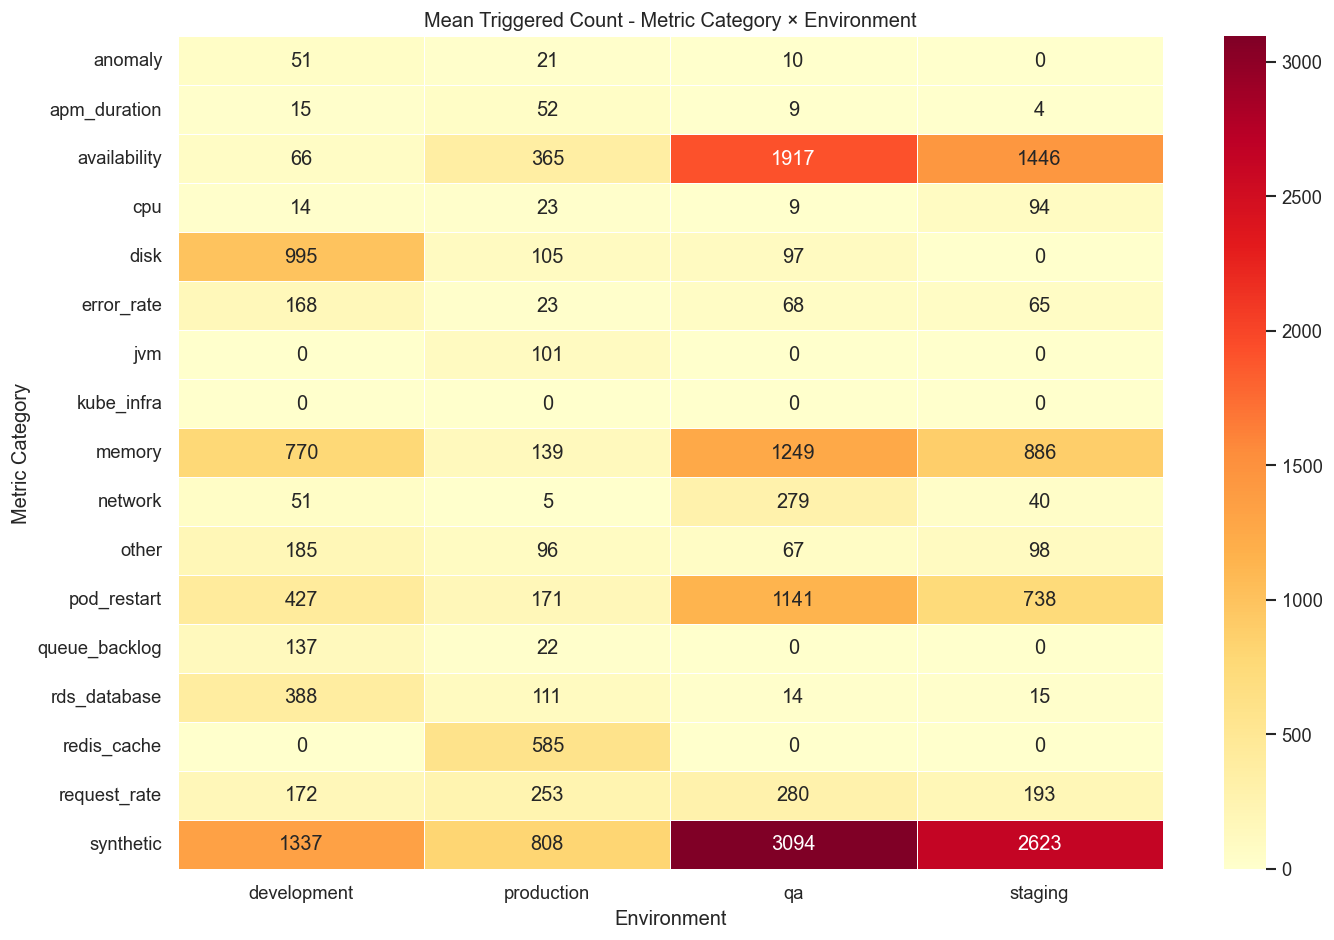

In [97]:
pivot = df.groupby(['metric_category', 'environment'])['triggered_count'].mean().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Mean Triggered Count - Metric Category × Environment')
ax.set_xlabel('Environment')
ax.set_ylabel('Metric Category')
plt.tight_layout()
plt.show()

## Outlier detection

Using Isolation Forest to see if there are alerts that look really different from the rest - extreme thresholds, way too many triggers, etc.

In [98]:
features_for_outlier = ['threshold', 'inertia_ms', 'triggered_count', 'check_interval_min', 'notification_count']
df_outlier = df[features_for_outlier].dropna().copy()

iso_forest = IsolationForest(contamination=0.05, random_state=42)
df.loc[df_outlier.index, 'outlier'] = iso_forest.fit_predict(df_outlier)
df['outlier'] = df['outlier'].map({1: 'Normal', -1: 'Outlier'}).fillna('Excluded')

print(df['outlier'].value_counts())
print(f"\nOutlier rate: {(df['outlier']=='Outlier').mean()*100:.1f}%")

outlier
Normal      43117
Outlier      2173
Excluded      671
Name: count, dtype: int64

Outlier rate: 4.7%


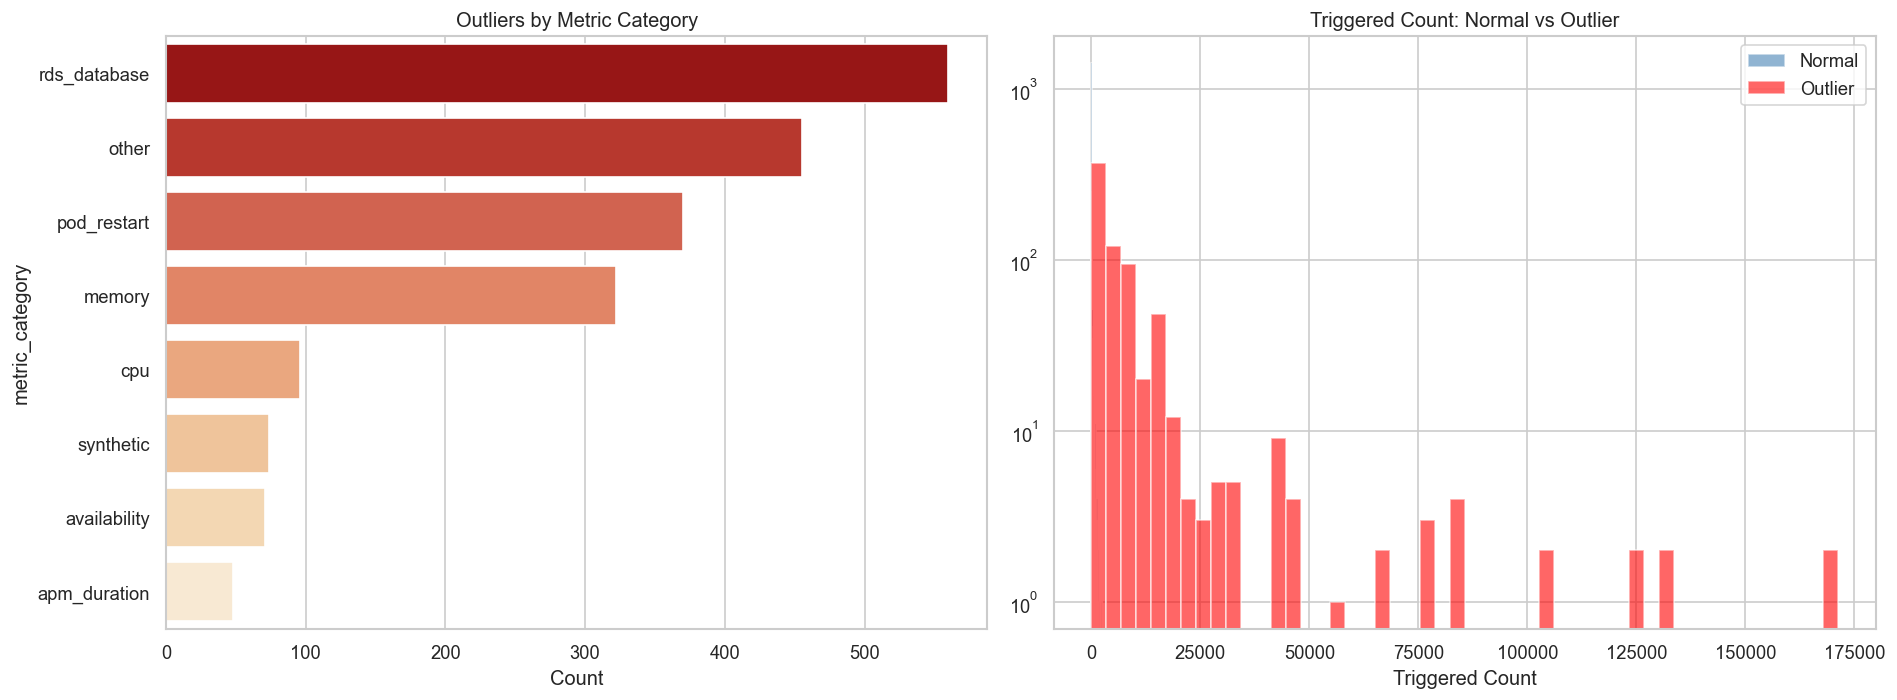


Outlier stats:
          threshold   inertia_ms  triggered_count  check_interval_min  \
count  2.173000e+03       2173.0           2173.0              2173.0   
mean   1.132294e+10    1923120.8           2736.7                16.7   
std    1.472213e+11    6192103.5          10911.8                19.4   
min   -4.000000e+00          0.0              0.0                 1.0   
25%    1.000000e+00     300000.0              0.0                 2.0   
50%    7.500000e+01     600000.0              0.0                10.0   
75%    1.073742e+09    3300000.0            658.0                15.0   
max    5.497558e+12  172800000.0         171306.0                60.0   

       notification_count  
count              2173.0  
mean                  1.9  
std                   1.1  
min                   0.0  
25%                   1.0  
50%                   2.0  
75%                   3.0  
max                   5.0  


In [99]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

outlier_df = df[df['outlier'] == 'Outlier']
out_metrics = outlier_df['metric_category'].value_counts().head(8)
sns.barplot(x=out_metrics.values, y=out_metrics.index, ax=axes[0], palette='OrRd_r')
axes[0].set_title('Outliers by Metric Category')
axes[0].set_xlabel('Count')

normal_triggered = df[(df['outlier'] == 'Normal') & (df['triggered_count'] > 0)]['triggered_count']
outlier_triggered = df[(df['outlier'] == 'Outlier') & (df['triggered_count'] > 0)]['triggered_count']
axes[1].hist(normal_triggered, bins=50, alpha=0.6, label='Normal', color='steelblue')
axes[1].hist(outlier_triggered, bins=50, alpha=0.6, label='Outlier', color='red')
axes[1].set_yscale('log')
axes[1].set_title('Triggered Count: Normal vs Outlier')
axes[1].set_xlabel('Triggered Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nOutlier stats:")
print(df[df['outlier']=='Outlier'][features_for_outlier].describe().round(1))

## PagerDuty Incident Analysis

I now have real PagerDuty incident data (2,035 incidents over 29 days). The enriched dataset links alerts to actual PD pages via the product+service prefix. I filter to "signal" alerts (≤10 incidents/month) to separate actionable incidents from chronic noise.

PagerDuty alerts that actually fired: 617
                 num_alerts  total_triggers  avg_triggers
metric_category                                          
memory                   64          266582        4165.3
disk                     14           79380        5670.0
other                   106           78594         741.5
pod_restart              31           32796        1057.9
rds_database             21           19048         907.0
error_rate              124            8837          71.3
availability             40            5500         137.5
synthetic                43            3783          88.0
apm_duration             78            3090          39.6
cpu                      44            1488          33.8


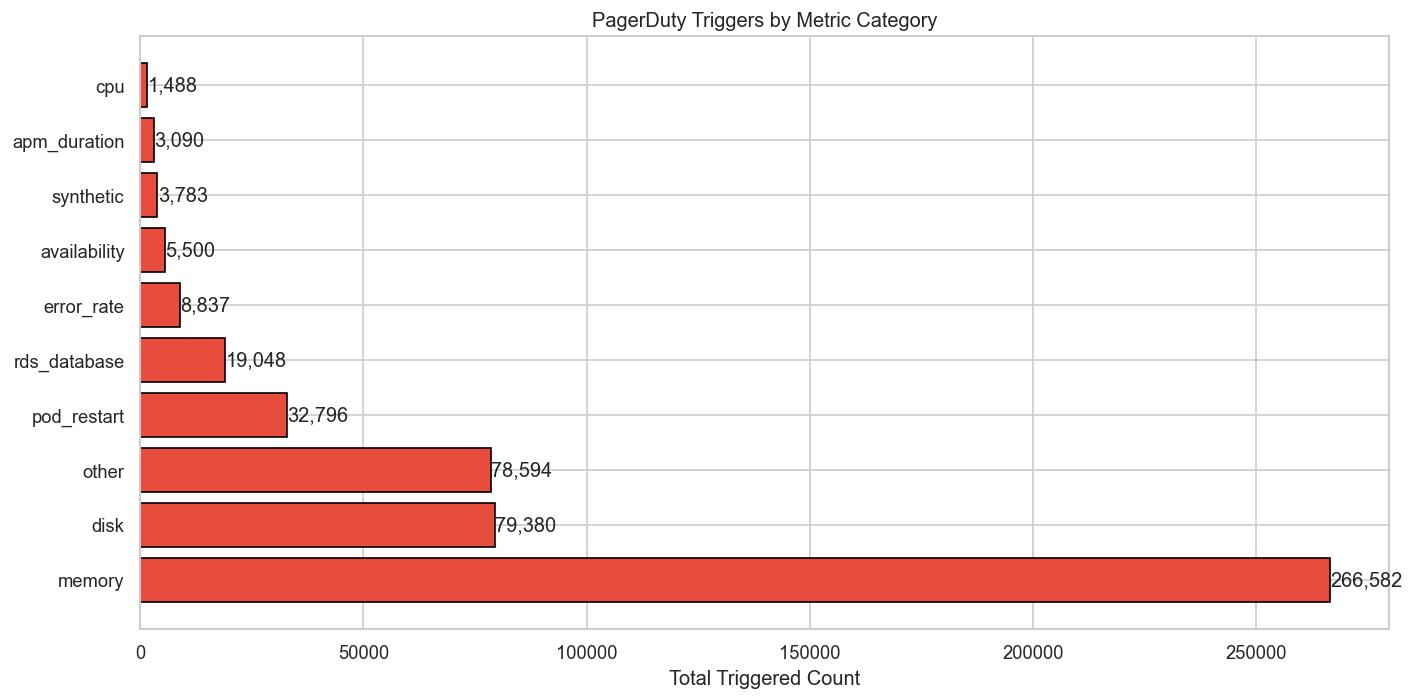

In [100]:
pd_triggered = df[(df['has_pagerduty'] == True) & (df['triggered_count'] > 0)].copy()
print(f"PagerDuty alerts that actually fired: {len(pd_triggered):,}")

pd_cat = pd_triggered.groupby('metric_category')['triggered_count'].agg(['count', 'sum', 'mean']).sort_values('sum', ascending=False)
pd_cat.columns = ['num_alerts', 'total_triggers', 'avg_triggers']
print(pd_cat.head(10).round(1))

fig, ax = plt.subplots(figsize=(12, 6))
pd_cat_top = pd_cat.head(10)
ax.barh(pd_cat_top.index, pd_cat_top['total_triggers'], color='#e74c3c', edgecolor='black')
ax.set_title('PagerDuty Triggers by Metric Category')
ax.set_xlabel('Total Triggered Count')
for i, v in enumerate(pd_cat_top['total_triggers']):
    ax.text(v + 100, i, f'{v:,.0f}', va='center')
plt.tight_layout()
plt.show()

## Baseline Model

Running a quick Random Forest to predict incident-prone alerts using the real PagerDuty-derived target. An alert is labeled positive if its product+service combination triggered actionable PD incidents (≤10/month, filtering out chronic flapping).

The class imbalance is 11:1 - much more manageable than the previous 59:1 proxy.

In [101]:
# Real target from PagerDuty incident data
df['high_trigger'] = df['target_incident'].fillna(0).astype(int)

print(f"Target: alert's product+service caused actionable PD incidents (≤10/month)")
print(f"\nClass distribution:")
print(df['high_trigger'].value_counts())
print(f"\nImbalance ratio: {df['high_trigger'].value_counts()[0] / df['high_trigger'].value_counts()[1]:.1f}:1")

Target: alert's product+service caused actionable PD incidents (≤10/month)

Class distribution:
high_trigger
0    42156
1     3805
Name: count, dtype: int64

Imbalance ratio: 11.1:1


In [102]:
feature_cols = ['enabled', 'has_pagerduty', 'threshold', 'inertia_ms', 'check_interval_min',
                'notification_count', 'alert_age_days', 'triggered_count']
cat_cols = ['metric_category', 'environment', 'trigger_type']

df_model = df.dropna(subset=feature_cols + cat_cols).copy()

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col])
    le_dict[col] = le

X = df_model[feature_cols + [c + '_enc' for c in cat_cols]].copy()
X['enabled'] = X['enabled'].astype(int)
X['has_pagerduty'] = X['has_pagerduty'].astype(int)
y = df_model['high_trigger']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train positive rate: {y_train.mean():.3f} | Test positive rate: {y_test.mean():.3f}")

Train: 36,232  |  Test: 9,058
Train positive rate: 0.084 | Test positive rate: 0.084


In [103]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['No Incident', 'Incident-Prone']))

                precision    recall  f1-score   support

   No Incident       0.98      0.81      0.89      8298
Incident-Prone       0.30      0.86      0.44       760

      accuracy                           0.82      9058
     macro avg       0.64      0.84      0.67      9058
  weighted avg       0.93      0.82      0.85      9058



## Takeaways

- **Most common alert categories** are APM duration (23.6%) and memory (16.3%), followed by CPU (13.9%) and error rate (11.3%). The improved classification reduced the catch-all "other" bucket from 38% to ~11%.
- **Production is ~81% of the data.** Staging/dev have a different profile - more infra (CPU, memory) vs application metrics.
- **Non-PagerDuty alerts have a higher mean trigger count** (188.9) than PagerDuty ones (33.0). PD alerts may be better tuned, or non-PD alerts are noisy without anyone noticing.
- **93.4% of alert-trigger pairs have never fired.** That's a lot of potentially dead alerts worth investigating.
- **Isolation Forest flagged ~5% as outliers** - mostly alerts with extreme thresholds or trigger counts.
- **Target is now PagerDuty-derived.** Alerts whose product+service combination triggered actionable PD incidents (≤10/month) are labeled positive (~3,800 positives, 11:1 imbalance - much better than the previous 59:1 proxy).
- **Baseline Random Forest confirms the features work.** Full model comparison with hyperparameter tuning in the [Modeling notebook](Modeling.ipynb).